# Liberal/Conservative Topic Modeling

In this section we explore ideological differences in Reddit posts using BERTopic. We will:

1. Load our cleaned “title + body” corpus and map each post to its political lean (Liberal → 0, Conservative → 1).
2. Fit BERTopic to discover an automatic set of topics and extract the full document–topic probability matrix.
3. Train a class-weighted Logistic Regression on these probabilities, reporting CV AUC and balanced accuracy, plus a confusion matrix on a held-out test split.
4. Reduce the model to 30 topics for interpretability, then identify the top-skewed Liberal and Conservative topics as well as common themes.
5. Visualize each topic’s top non–stopword keywords and analyze whether the highest-scoring posts align with their class’s core topics.

### Imports

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import re
import nltk
from nltk.corpus import stopwords
from bertopic import BERTopic
from sklearn.linear_model              import LogisticRegression
from sklearn.model_selection           import cross_val_score, train_test_split
from sklearn.metrics                   import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.feature_extraction.text   import CountVectorizer

/opt/anaconda3/envs/text-analytics/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


# Data preparation

In [2]:
# load the dataset
df = pd.read_csv('data/reddit_posts_further_reduced.csv')

In [3]:
# Convert to date to datetime and rename columns
df['Date Created'] = pd.to_datetime(df['Date Created'], unit='s')
df = df.rename(columns={"Title": "title", "Text": "selftext"})

In [4]:
# Clean the text
def minimal_clean(text: str) -> str:
    if pd.isna(text):
        return ""
    # Lowercase
    text = text.lower()
    # Remove URLs
    text = re.sub(r"https?://\S+", "", text)
    # Collapse multiple spaces
    text = re.sub(r"\s+", " ", text).strip()
    return text

# clean the df
df["title_clean"]    = df["title"].apply(minimal_clean)
df["selftext_clean"] = df["selftext"].apply(minimal_clean)

## Topic Modeling

In [5]:
# combine into docs for bertopic
docs = (df["title_clean"] + " " + df["selftext_clean"].fillna("")).tolist()
y = df["Political Lean"].map({"Liberal": 0, "Conservative": 1})

In [18]:
# Fit BERTopic with full probability matrix
topic_model = BERTopic(embedding_model="all-mpnet-base-v2", calculate_probabilities=True, verbose=True, top_n_words =30)
topics, probs = topic_model.fit_transform(docs)

2025-06-05 11:07:08,793 - BERTopic - Embedding - Transforming documents to embeddings.
Batches: 100%|██████████| 313/313 [01:03<00:00,  4.93it/s]
2025-06-05 11:08:14,746 - BERTopic - Embedding - Completed ✓
2025-06-05 11:08:14,747 - BERTopic - Dimensionality - Fitting the dimensionality reduction algorithm
2025-06-05 11:08:17,806 - BERTopic - Dimensionality - Completed ✓
2025-06-05 11:08:17,807 - BERTopic - Cluster - Start clustering the reduced embeddings
2025-06-05 11:08:23,149 - BERTopic - Cluster - Completed ✓
2025-06-05 11:08:23,152 - BERTopic - Representation - Extracting topics from clusters using representation models.
2025-06-05 11:08:23,380 - BERTopic - Representation - Completed ✓


### Liberal vs Conservative classification

5-fold CV AUC: 0.708 ± 0.040
5-fold CV Balanced Accuracy: 0.626 ± 0.017
              precision    recall  f1-score   support

     Liberal       0.79      0.78      0.78      1285
Conservative       0.61      0.62      0.62       715

    accuracy                           0.72      2000
   macro avg       0.70      0.70      0.70      2000
weighted avg       0.72      0.72      0.72      2000



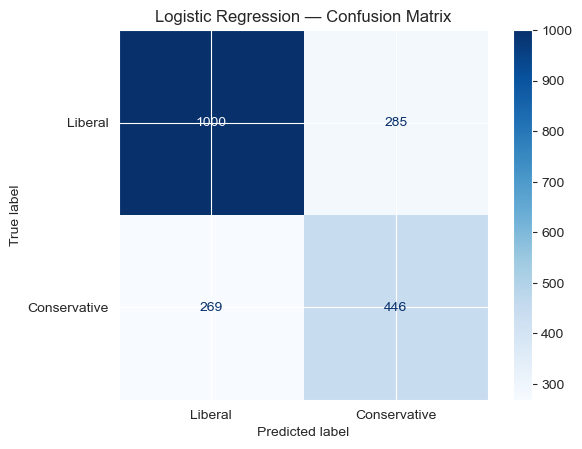

In [13]:
# Evaluate with 5-fold CV AUC
X = np.array(probs)                     # shape: (n_docs, n_topics)
clf = LogisticRegression(max_iter=1000, class_weight="balanced")
auc_scores = cross_val_score(clf, X, y, cv=5, scoring="roc_auc")
print(f"5-fold CV AUC: {auc_scores.mean():.3f} ± {auc_scores.std():.3f}")
bal_scores = cross_val_score(clf, X, y, cv=5, scoring="balanced_accuracy")
print(f"5-fold CV Balanced Accuracy: {bal_scores.mean():.3f} ± {bal_scores.std():.3f}") # used balanced accuracy because our classes are imbalanced

# Train/test split for confusion matrix
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)
clf.fit(X_train, y_train)
y_pred = clf.predict(X_test)

print(classification_report(y_test, y_pred, target_names=["Liberal","Conservative"]))
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=["Liberal","Conservative"])
disp.plot(cmap="Blues")
plt.title("Logistic Regression — Confusion Matrix")
plt.show()

### Reduction to 30 Topics and Topic analysis

In [20]:
# reduce the topic model to 30 topics and save it, uncomment to run it or just used the saved topic model in data/bertopic_model
'''
# Immediately merge down to 30 topics for interpretability
topic_model.reduce_topics(docs, nr_topics=30)
# Re‐transform to get the probabilities over those 30 reduced topics
new_topics, new_probs = topic_model.transform(docs)
# Save the entire model to a file
model_path = "data/bertopic_model"
topic_model.save(model_path)
'''

2025-06-05 11:13:52,280 - BERTopic - Topic reduction - Reducing number of topics
2025-06-05 11:13:52,486 - BERTopic - Topic reduction - Reduced number of topics from 159 to 30
Batches: 100%|██████████| 313/313 [01:05<00:00,  4.81it/s]
2025-06-05 11:14:57,840 - BERTopic - Dimensionality - Reducing dimensionality of input embeddings.
2025-06-05 11:14:57,889 - BERTopic - Dimensionality - Completed ✓
2025-06-05 11:14:57,890 - BERTopic - Clustering - Approximating new points with `hdbscan_model`
2025-06-05 11:14:58,056 - BERTopic - Probabilities - Start calculation of probabilities with HDBSCAN
2025-06-05 11:15:03,480 - BERTopic - Probabilities - Completed ✓
2025-06-05 11:15:03,480 - BERTopic - Cluster - Completed ✓


In [6]:
# load the saved topic model to keep the exact same output after running several times
topic_model = BERTopic.load('data/bertopic_model')
new_topics, new_probs = topic_model.transform(docs)
topic_model.get_topic_info()

Batches: 100%|██████████| 313/313 [01:09<00:00,  4.48it/s]


,Topic,Count,Name,Representation,Representative_Docs
0,-1,3917,-1_the_of_and_to,"[the, of, and, to, in, for, that, is, it, on, ...",[austrias revolutionary for social welfare - f...
1,0,853,0_the_of_and_to,"[the, of, and, to, is, that, in, you, it, capi...",[explaining the marxist methodology (wall of t...
2,1,658,1_biden_trump_to_for,"[biden, trump, to, for, joe, court, on, the, s...","[what has biden done , is this war going to be..."
3,2,604,2_ukraine_russia_russian_china,"[ukraine, russia, russian, china, the, to, and...",[the kremlin just sold out a generation i'm ru...
4,3,389,3_to_voting_the_in,"[to, voting, the, in, republicans, and, are, o...",[is it too late to save american democracy? i'...
5,4,327,4_whatever_you_weekly_unrelated,"[whatever, you, weekly, unrelated, please, ent...",[weekly discussion thread [55] feel free to di...
6,5,312,5_the_to_of_and,"[the, to, of, and, is, that, libertarian, peop...","[blowing the communist's ""nazis and fascist we..."
7,6,279,6_trudeau_police_canada_the,"[trudeau, police, canada, the, convoy, to, and...",[as a canadian this is the first time i've got...
8,7,259,7_trump_durham_probe_donald,"[trump, durham, probe, donald, committee, inve...",[new york prosecutors leading trump probe resi...
9,8,246,8_covid_health_the_insurance,"[covid, health, the, insurance, to, of, health...",[how to pay less for medicines: what can be le...


we can see that we have a lot of stopwords in many of the topic, we will filter them out to keep only the words with sementic meaning.

In [7]:
# load stop-words
nltk.download("stopwords", quiet=True)
stop_words = set(stopwords.words("english"))

# Find top-skew topics per class
probs_df = pd.DataFrame(new_probs, columns=range(new_probs.shape[1]))
probs_df["class"] = y.values
mean_by_class = probs_df.groupby("class").mean()
diff = mean_by_class.loc[1] - mean_by_class.loc[0]

top_cons = diff.nlargest(8).index.tolist()
top_lib  = diff.nsmallest(8).index.tolist()

print("Top Conservative topics:", top_cons)
print("Top Liberal topics:     ", top_lib)

#  Print each topic’s top words, filtering out stop-words
for tid in top_cons:
    print(f"\n=== Topic {tid} (Conservative) ===")
    raw_keywords = topic_model.get_topic(tid)  # returns default list of top 20 (word, score)
    filtered     = [(w, s) for (w, s) in raw_keywords if w not in stop_words]
    for w, score in filtered[:10]:  # show top 10 non-stop-words
        print(f"  {w:15} {score:.4f}")

for tid in top_lib:
    print(f"\n=== Topic {tid} (Liberal) ===")
    raw_keywords = topic_model.get_topic(tid)
    filtered     = [(w, s) for (w, s) in raw_keywords if w not in stop_words]
    for w, score in filtered[:10]:
        print(f"  {w:15} {score:.4f}")

Top Conservative topics: [2, 17, 1, 6, 0, 13, 9, 18]
Top Liberal topics:      [10, 3, 11, 14, 15, 12, 21, 24]

=== Topic 2 (Conservative) ===
  ukraine         0.0535
  russia          0.0388
  russian         0.0274
  china           0.0250
  nato            0.0201
  putin           0.0180
  war             0.0165
  us              0.0154
  invasion        0.0141
  ukrainian       0.0125

=== Topic 17 (Conservative) ===
  desantis        0.3396
  florida         0.1462
  ron             0.1307
  gov             0.0879
  poll            0.0471
  cpac            0.0432
  orlando         0.0404
  trump           0.0344
  governor        0.0333
  gofundme        0.0307

=== Topic 1 (Conservative) ===
  biden           0.0880
  trump           0.0273
  joe             0.0200
  court           0.0181
  supreme         0.0165
  president       0.0141
  putin           0.0139
  ukraine         0.0137
  russia          0.0129
  manchin         0.0127

=== Topic 6 (Conservative) ===
  trudeau  

In [8]:
# per‐class mean probabilities
probs_df_2    = pd.DataFrame(new_probs, columns=range(new_probs.shape[1]))
probs_df_2["class"] = y.values   # 0=Liberal, 1=Conservative
mean_by_class = probs_df_2.groupby("class").mean()

#       For each topic t, record:
#       a) mean_L = mean_by_class.loc[0, t]
#       b) mean_C = mean_by_class.loc[1, t]
#       c) abs_diff = |mean_C − mean_L|
#       d) overall_mean = (mean_C + mean_L) / 2
diff = (mean_by_class.loc[1] - mean_by_class.loc[0]).abs()
overall_mean = (mean_by_class.loc[1] + mean_by_class.loc[0]) / 2

# Assemble into a DataFrame to sort/filter
common_df = pd.DataFrame({
    "mean_L":       mean_by_class.loc[0],
    "mean_C":       mean_by_class.loc[1],
    "abs_diff":     diff,
    "overall_mean": overall_mean
})

# Find topics with the smallest absolute difference
common_df = common_df.sort_values(["abs_diff", "overall_mean"], ascending=[True, False])

# only pick topics that both sides discuss at a non‐trivial rate (overall_mean > 0.02)
common_df = common_df[common_df["overall_mean"] > 0.02]

# Pick the top 5 “common” topics
top_common = common_df.index.tolist()[:5]

print("Top “common” topics (same prominence in both classes):", top_common)
print(common_df.loc[top_common])

# Display their keywords (filter out stop‐words)
import nltk
from nltk.corpus import stopwords
nltk.download("stopwords", quiet=True)
stop_words = set(stopwords.words("english"))

for tid in top_common:
    raw_keywords = topic_model.get_topic(tid)
    filtered     = [(w, s) for (w, s) in raw_keywords if w not in stop_words]
    print(f"\n=== Topic {tid} (common) ===")
    for w, score in filtered[:10]:
        print(f"  {w:15} {score:.4f}")


Top “common” topics (same prominence in both classes): [8, 4, 7, 5, 9]
     mean_L    mean_C  abs_diff  overall_mean
8  0.026060  0.025483  0.000577      0.025772
4  0.021337  0.020559  0.000778      0.020948
7  0.033555  0.034392  0.000837      0.033973
5  0.029344  0.034239  0.004895      0.031792
9  0.021431  0.027650  0.006219      0.024541

=== Topic 8 (common) ===
  covid           0.0311
  health          0.0289
  insurance       0.0254
  healthcare      0.0212
  vaccine         0.0172
  19              0.0144
  administration  0.0144
  pandemic        0.0134
  care            0.0133
  mask            0.0127

=== Topic 4 (common) ===
  whatever        0.0817
  weekly          0.0531
  unrelated       0.0521
  please          0.0498
  entirely        0.0463
  socdem          0.0463
  thread          0.0463
  related         0.0437
  discuss         0.0436
  discussion      0.0389

=== Topic 7 (common) ===
  trump           0.1576
  durham          0.0574
  probe           0.0393


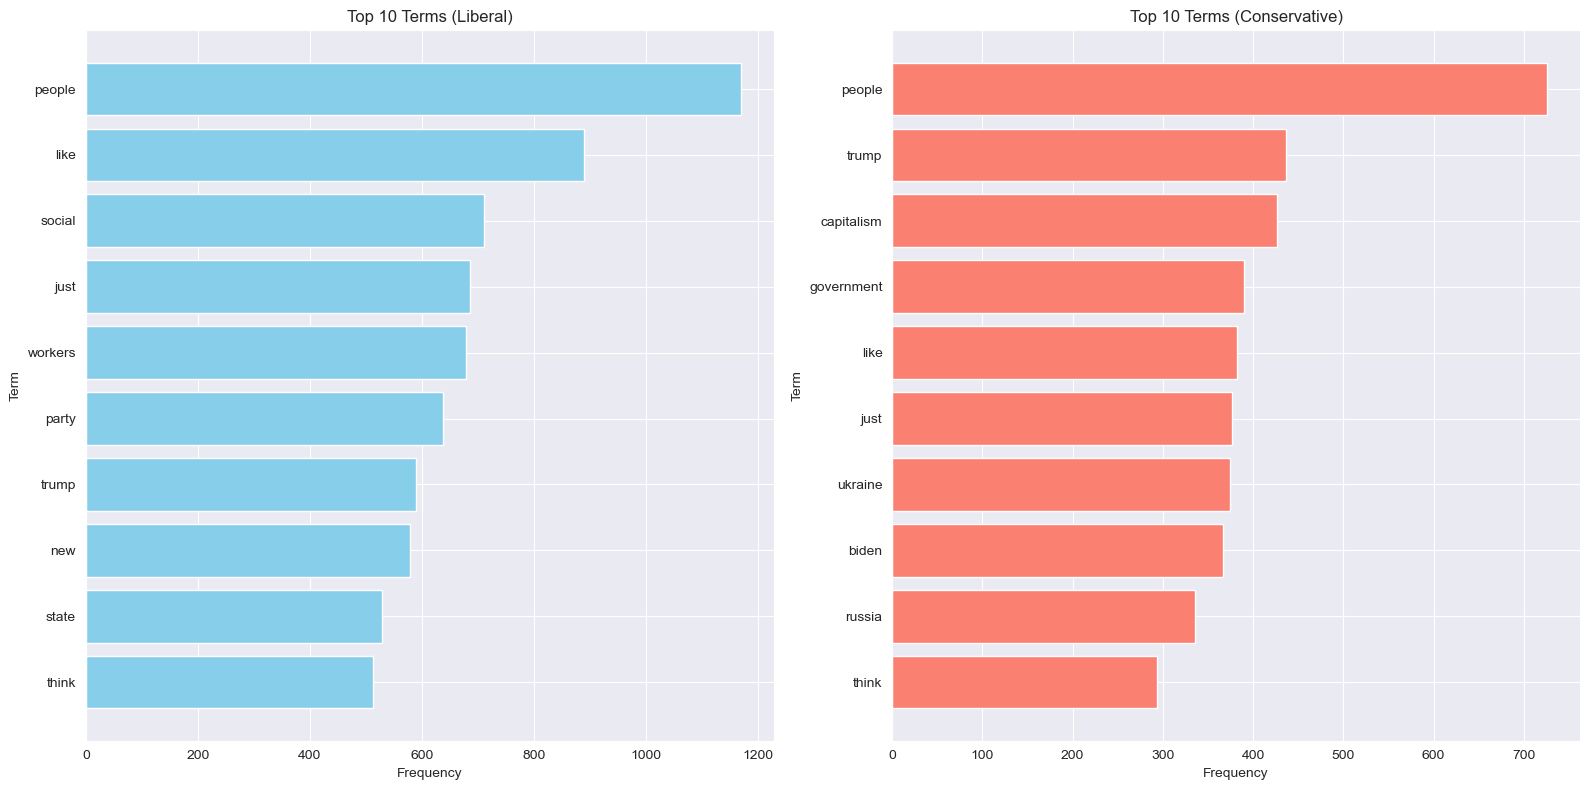

In [9]:
# Raw 2-gram vocabulary comparison
vectorizer = CountVectorizer(stop_words="english", ngram_range=(1,2), max_features=5000)
X_cv = vectorizer.fit_transform(docs)
vocab = vectorizer.get_feature_names_out()

vocab_df = pd.DataFrame(X_cv.toarray(), columns=vocab)
vocab_df["class"] = y.values
counts = vocab_df.groupby("class").sum()

#  Extract top 10 terms for each class
top10_lib = counts.loc[0].nlargest(10)
top10_con = counts.loc[1].nlargest(10)

#  Plot bar charts
fig, axes = plt.subplots(1, 2, figsize=(16, 8))

# Liberal chart
axes[0].barh(top10_lib.index[::-1], top10_lib.values[::-1], color='skyblue')
axes[0].set_title("Top 10 Terms (Liberal)")
axes[0].set_xlabel("Frequency")
axes[0].set_ylabel("Term")

# Conservative chart
axes[1].barh(top10_con.index[::-1], top10_con.values[::-1], color='salmon')
axes[1].set_title("Top 10 Terms (Conservative)")
axes[1].set_xlabel("Frequency")
axes[1].set_ylabel("Term")

plt.tight_layout()
plt.show()

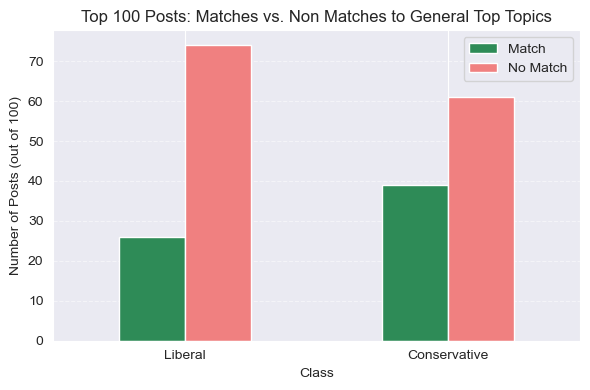


=== Example Posts ===

--- Liberal Examples (Top 100 by norm_score) ---
General top topics for Liberal: [10, 3, 11, 14, 15, 12, 21]

1. Title: "class warfare"
   • Assigned Topic: 0 (the, of, and…)
   • Normalized Score: 1.000
   • In Top‐7 Topics? No

2. Title: "Rudy Giuliani Is Reportedly Close to Broke—and Donald Trump Isn’t Taking His Calls; That’s what happens when you go to bat for a notoriously cheap, friendless, crappy businessman."
   • Assigned Topic: 7 (trump, durham, probe…)
   • Normalized Score: 1.000
   • In Top‐7 Topics? No

3. Title: "On September 6, 2020 feminist activists broke into and occupied the national commission on human rights in Mexico City. The action was taken in protest against a state that does nothing to prevent the killing and rape of girls and women in Mexico"
   • Assigned Topic: 10 (women, her, she…)
   • Normalized Score: 1.000
   • In Top‐7 Topics? Yes

4. Title: "Remember who the enemy is:"
   • Assigned Topic: 0 (the, of, and…)
   • Normalized 

In [10]:
# Compute normalized score per subreddit
df["norm_score"] = df.groupby("Subreddit")["Score"].transform(lambda x: x / x.max())


#  Identify general top‐7 topics per class
probs_df_4 = pd.DataFrame(new_probs, columns=range(new_probs.shape[1]))
probs_df_4["class"] = y.values

mean_by_class = probs_df_4.groupby("class").mean()
diff = mean_by_class.loc[1] - mean_by_class.loc[0]  # Conservative minus Liberal

top_cons = diff.nlargest(7).index.tolist()
top_lib  = diff.nsmallest(7).index.tolist()

#  For each class, find the top‐100 posts by norm_score and check matches
top_n = 100
top_posts = {0: [], 1: []}

for cl in [0, 1]:
    subset = probs_df[probs_df["class"] == cl].copy()
    subset["norm_score"] = df.loc[subset.index, "norm_score"].values
    top_indices = subset.sort_values("norm_score", ascending=False).head(top_n).index.tolist()

    for idx in top_indices:
        row_probs = subset.loc[idx, subset.columns[:-2]].values  # only topic cols
        best_topic = int(np.argmax(row_probs))
        general_top = top_lib if cl == 0 else top_cons
        matches = best_topic in general_top

        top_posts[cl].append({
            "index":           idx,
            "title":           df.loc[idx, "title"],
            "norm_score":      float(subset.loc[idx, "norm_score"]),
            "best_topic":      best_topic,
            "matches_general": matches
        })

#  Count matches vs. non‐matches for each class
counts = {"Liberal": {"Match": 0, "No Match": 0},
          "Conservative": {"Match": 0, "No Match": 0}}

for cl, posts in top_posts.items():
    label = "Liberal" if cl == 0 else "Conservative"
    for p in posts:
        if p["matches_general"]:
            counts[label]["Match"] += 1
        else:
            counts[label]["No Match"] += 1

counts_df = pd.DataFrame(counts).T

fig, ax = plt.subplots(figsize=(6, 4), facecolor='none')
counts_df.plot(
    kind="bar",
    stacked=False,
    color=["seagreen", "lightcoral"],
    ax=ax
)
ax.set_title("Top 100 Posts: Matches vs. Non Matches to General Top Topics")
ax.set_ylabel("Number of Posts (out of 100)")
ax.grid(True, which="major", axis="y", linestyle="--", alpha=0.5)
ax.set_xlabel("Class")
plt.xticks(rotation=0)
plt.legend(title="")

plt.tight_layout()
fig.savefig(
    "match_vs_nomatch_top100.png",
    transparent=True,
    dpi=300,
    bbox_inches="tight"
)
plt.show()

# Print concrete examples
print("\n=== Example Posts ===")
for cl, posts in top_posts.items():
    label = "Liberal" if cl == 0 else "Conservative"
    print(f"\n--- {label} Examples (Top {top_n} by norm_score) ---")
    print(f"General top topics for {label}: {top_lib if cl==0 else top_cons}\n")
    for i, p in enumerate(posts, 1):
        tid = p["best_topic"]
        topic_keywd = [w for w,_ in topic_model.get_topic(tid)][:3]
        topic_label = ", ".join(topic_keywd)
        print(f"{i}. Title: \"{p['title']}\"")
        print(f"   • Assigned Topic: {tid} ({topic_label}…)")
        print(f"   • Normalized Score: {p['norm_score']:.3f}")
        print(f"   • In Top‐7 Topics? {'Yes' if p['matches_general'] else 'No'}\n")

### Visualization of the top words per topic

In [11]:
# Every Topic Top words list (filtering out stop-words)
topic_info = topic_model.get_topic_info()
all_tids   = topic_info[topic_info.Topic != -1]["Topic"].tolist() # remove the outlier topic

# For each topic ID, fetch its (word, score) list and filter stop-words
for tid in all_tids:
    raw_keywords = topic_model.get_topic(tid)
    filtered     = [(w, s) for (w, s) in raw_keywords if w not in stop_words]

    print(f"\n=== Topic {tid} ===")
    for w, score in filtered[:10]:                 # show top 10 non–stop-words
        print(f"  {w:15} {score:.4f}")


=== Topic 0 ===
  capitalism      0.0148
  social          0.0124
  socialism       0.0101
  people          0.0095

=== Topic 1 ===
  biden           0.0880
  trump           0.0273
  joe             0.0200
  court           0.0181
  supreme         0.0165
  president       0.0141
  putin           0.0139
  ukraine         0.0137
  russia          0.0129
  manchin         0.0127

=== Topic 2 ===
  ukraine         0.0535
  russia          0.0388
  russian         0.0274
  china           0.0250
  nato            0.0201
  putin           0.0180
  war             0.0165
  us              0.0154
  invasion        0.0141
  ukrainian       0.0125

=== Topic 3 ===
  voting          0.0241
  republicans     0.0181
  vote            0.0165
  election        0.0159
  democrats       0.0144
  party           0.0137
  would           0.0136
  texas           0.0135
  voters          0.0134
  arizona         0.0128

=== Topic 4 ===
  whatever        0.0817
  weekly          0.0531
  unrelated    

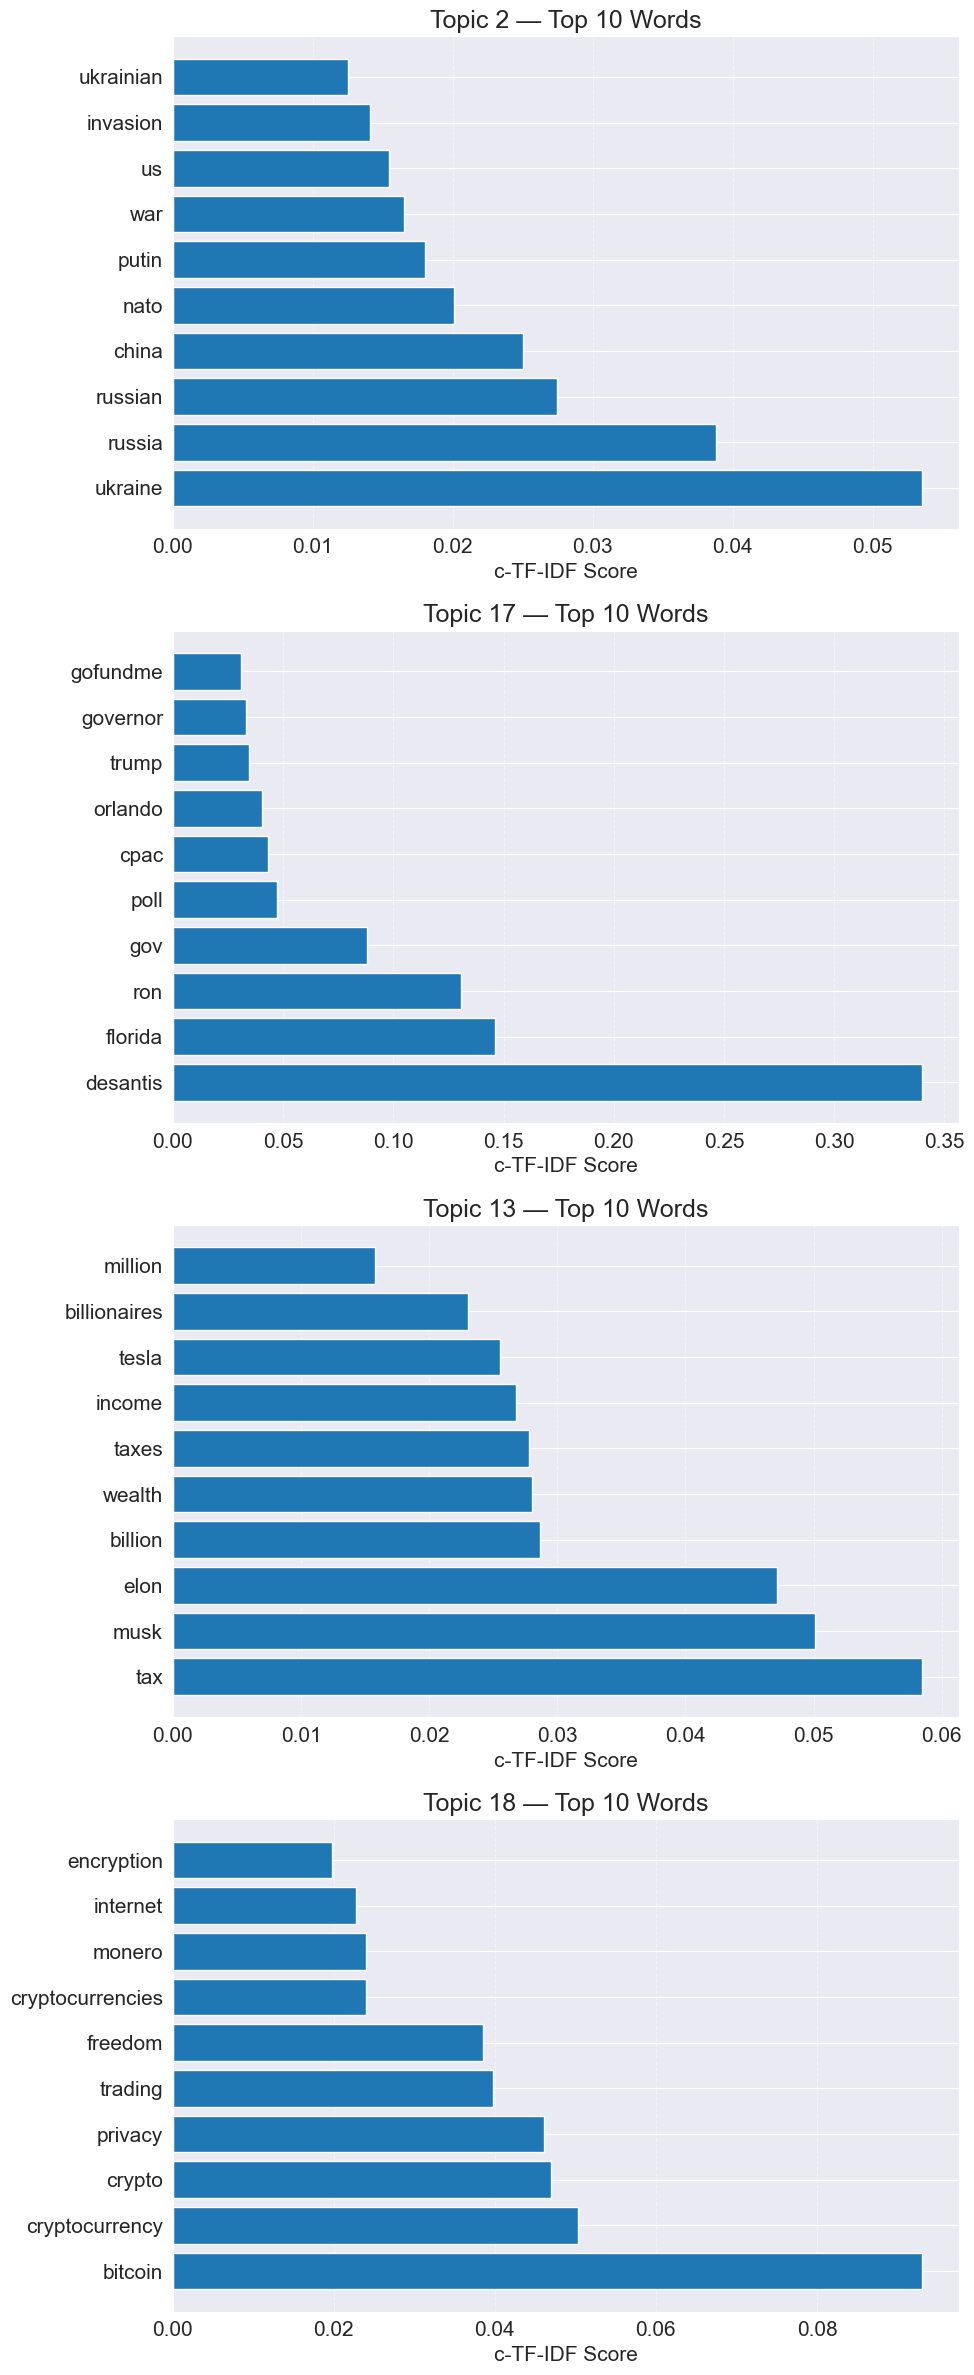

In [12]:
# Top conservative topics

plt.rcParams.update({'font.size': 15}) # Fix font-size

topic_ids = [2, 17, 13, 18]

# Number of top words to display per topic
top_n = 10


# layout
num_topics = len(topic_ids)
cols = 1
rows = int(np.ceil(num_topics / cols))
fig, axes = plt.subplots(rows, cols, figsize=(10, 6*rows))
axes = axes.flatten()

# Loop through each topic ID and create a bar chart
for idx, tid in enumerate(topic_ids):
    # Fetch all (word, score) pairs for this topic
    raw_keywords = topic_model.get_topic(tid)

    # Filter out any stopwords
    filtered = [(w, s) for (w, s) in raw_keywords if w not in stop_words]

    # Take the top_n after filtering
    top_keywords = filtered[:top_n]
    words, scores = zip(*top_keywords)

    # Plot on the appropriate subplot
    ax = axes[idx]
    ax.barh(range(len(words)), list(scores)[::-1])
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(list(words)[::-1])
    ax.invert_yaxis()  # Highest-score word at the top
    ax.set_title(f"Topic {tid} — Top {top_n} Words")
    ax.grid(True, which="major", axis="x", linestyle="--", alpha=0.5)
    ax.set_xlabel("c-TF-IDF Score")

plt.tight_layout()
fig.savefig(
    "conservative_topics.png",
    transparent=True,
    dpi=300,
    bbox_inches="tight"
) # save plot
plt.show()

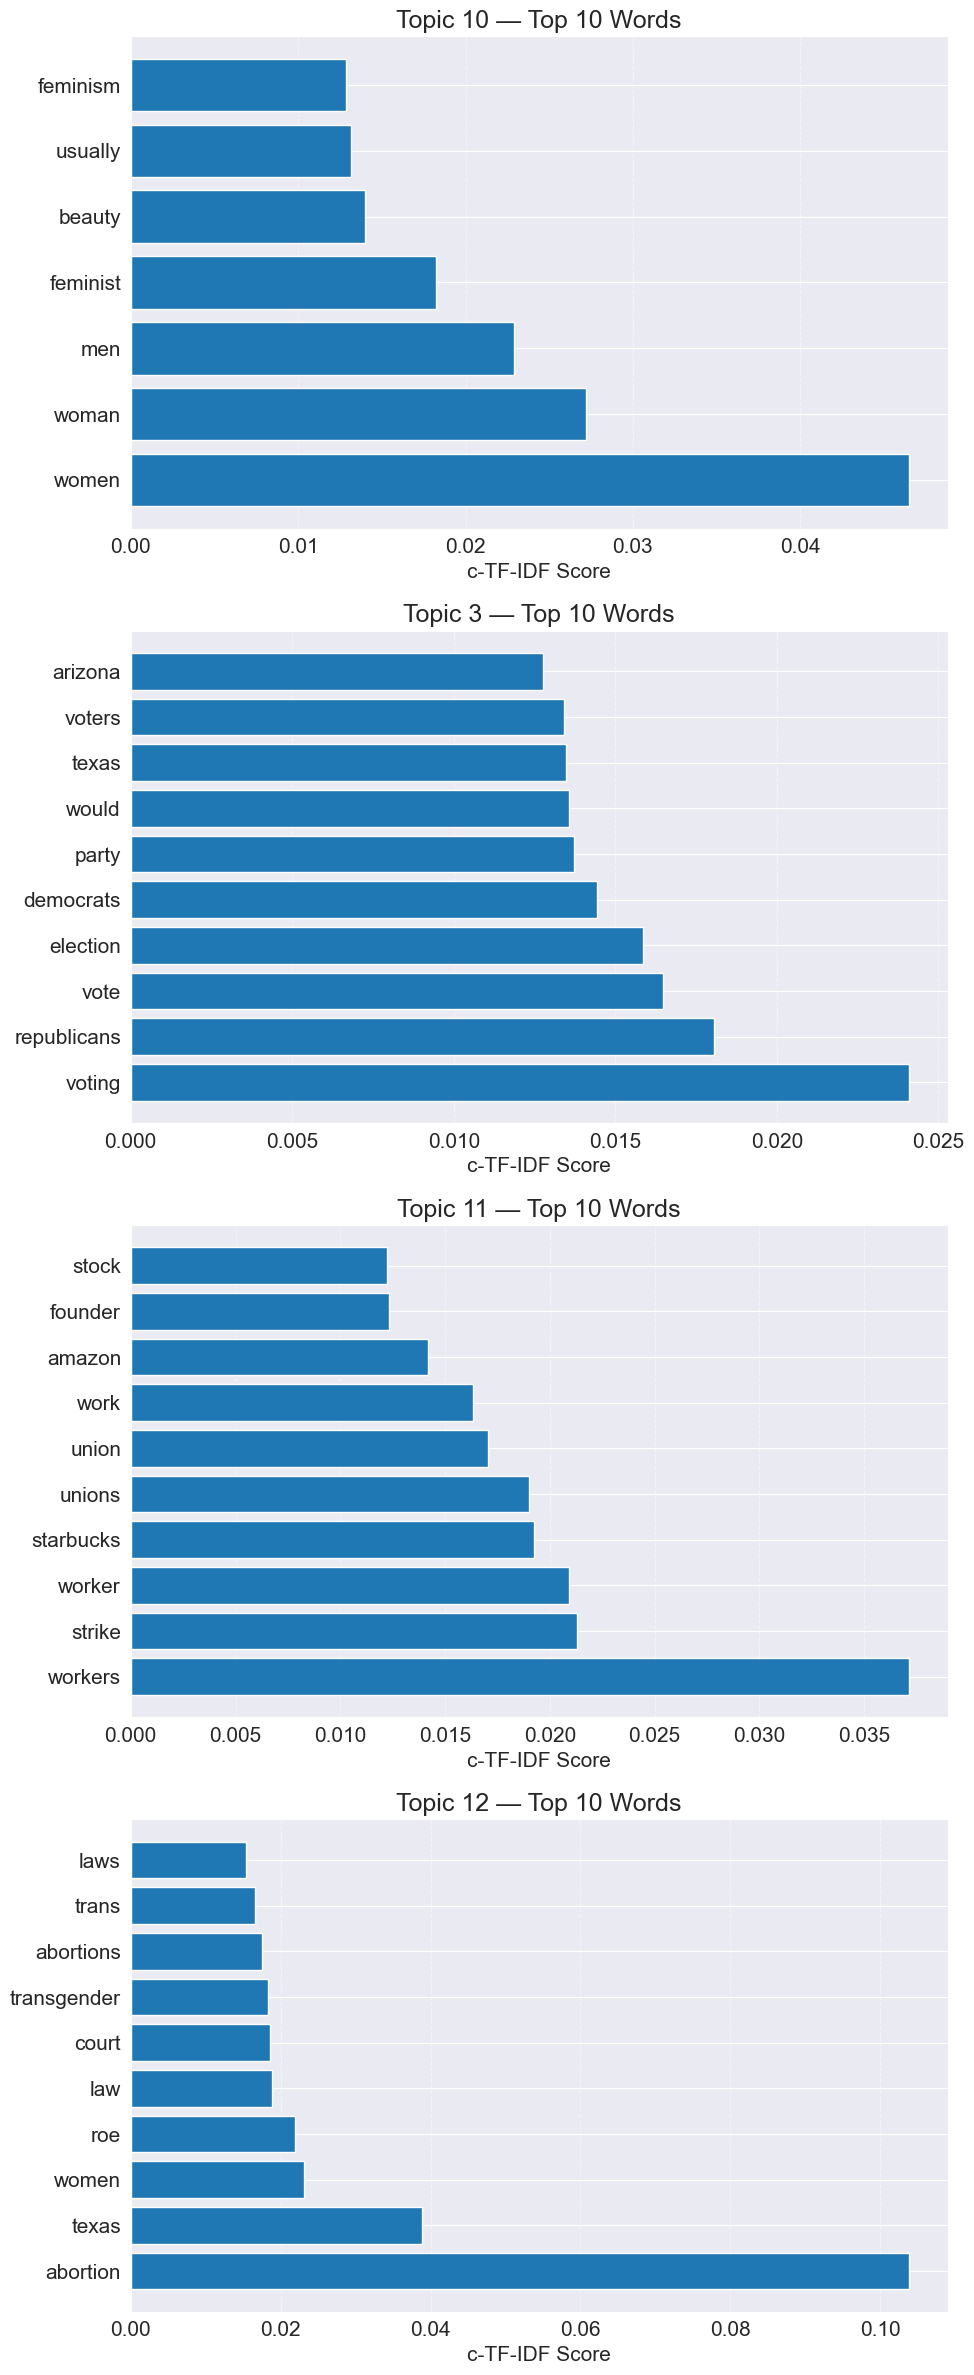

In [13]:
# Top conservative topics
top_n = 10
topic_ids = [10, 3, 11, 12]

# layout
fig, axes = plt.subplots(rows, cols, figsize=(10, 6 * rows))
axes = axes.flatten()

# Loop through each topic ID and create a bar chart
for idx, tid in enumerate(topic_ids):
    # Fetch all (word, score) pairs for this topic
    raw_keywords = topic_model.get_topic(tid)

    #  Filter out any stopwords
    filtered = [(w, s) for (w, s) in raw_keywords if w not in stop_words]

    # Take the top_n after filtering
    top_keywords = filtered[:top_n]
    words, scores = zip(*top_keywords)

    # Plot on the appropriate subplot
    ax = axes[idx]
    ax.barh(range(len(words)), list(scores)[::-1])
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(list(words)[::-1])
    ax.invert_yaxis()  # Highest-score word at the top
    ax.set_title(f"Topic {tid} — Top {top_n} Words")
    ax.grid(True, which="major", axis="x", linestyle="--", alpha=0.5)
    ax.set_xlabel("c-TF-IDF Score")

plt.tight_layout()
fig.savefig(
    "liberal_topics.png",
    transparent=True,
    dpi=300,
    bbox_inches="tight"
) # save plot
plt.show()

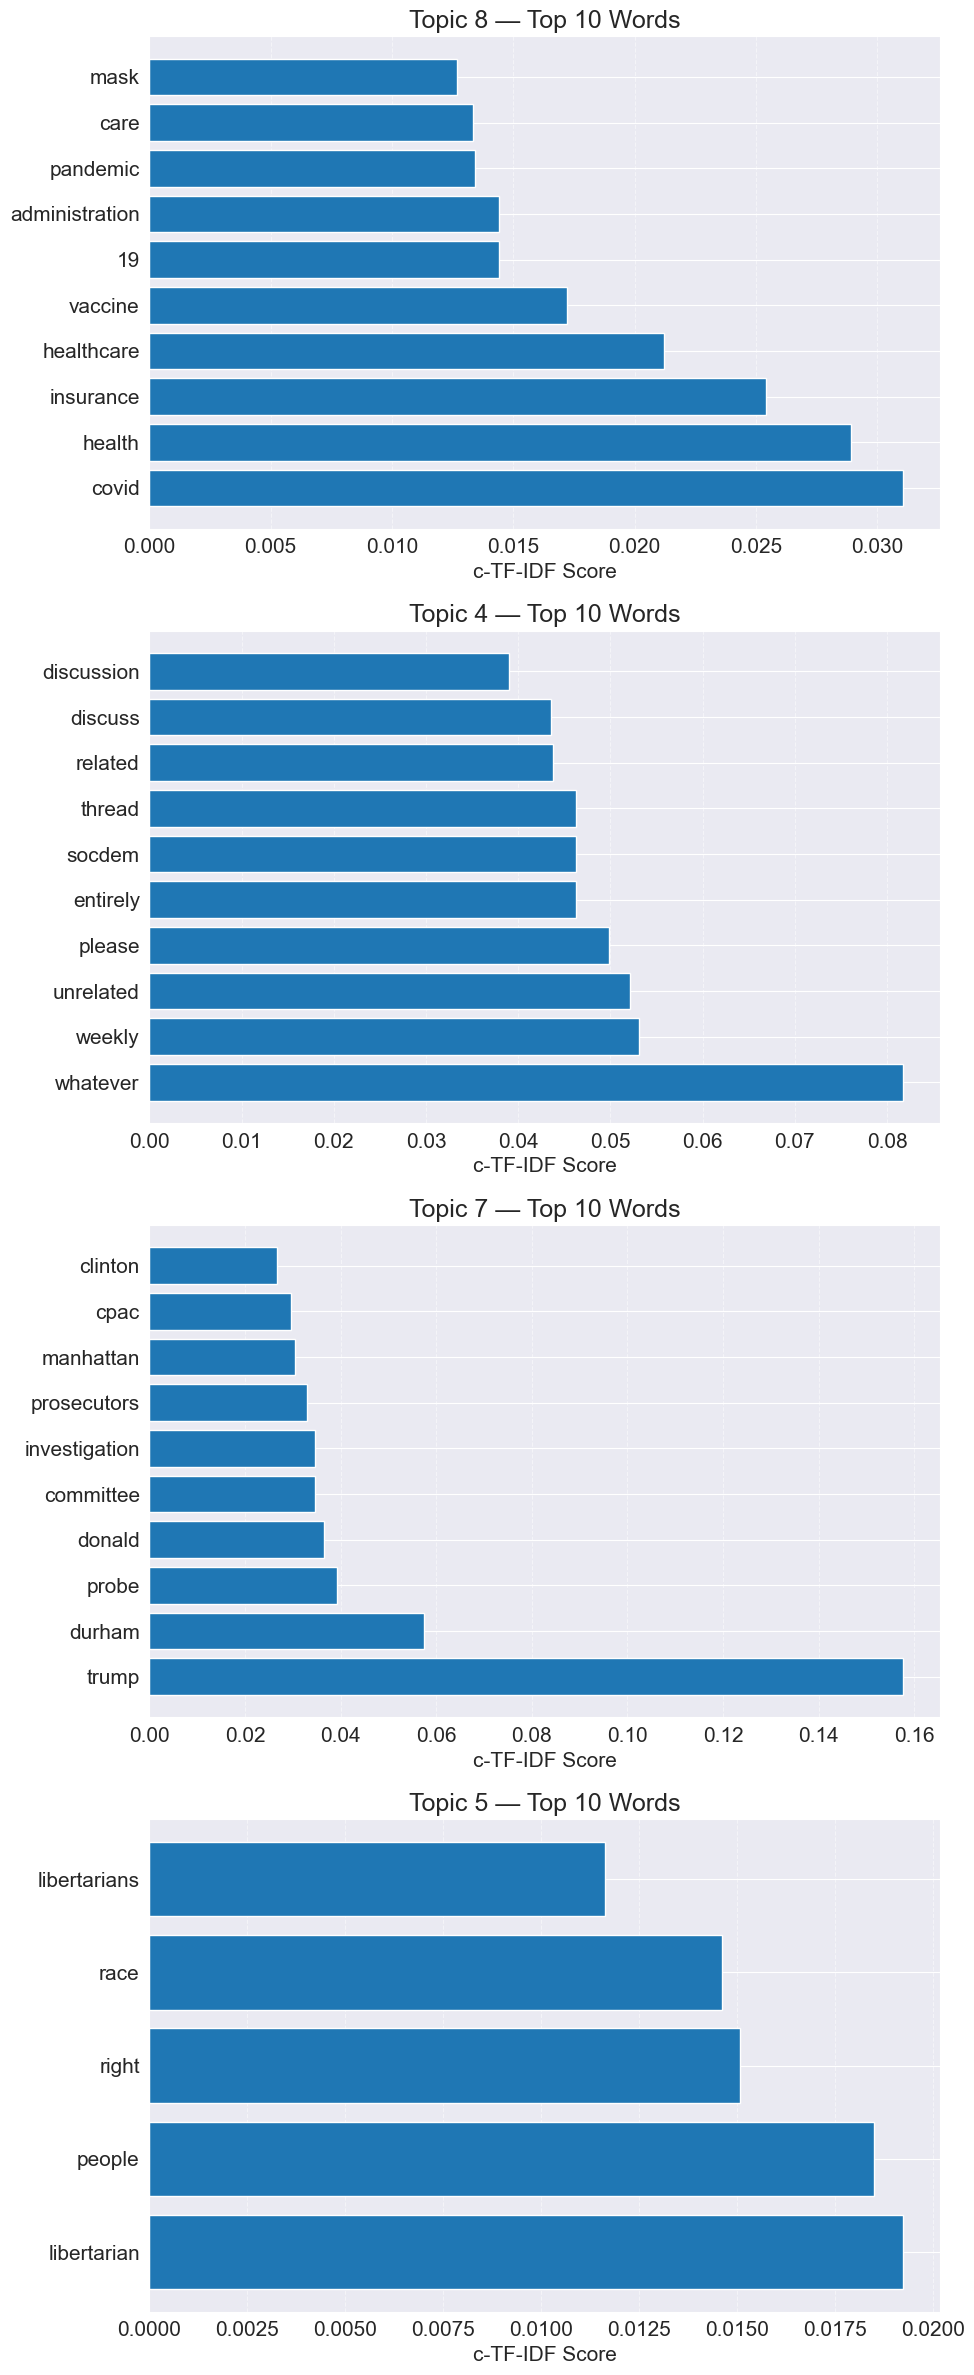

In [14]:
# Common Topics
topic_ids = [8, 4, 7, 5]

# layout
fig, axes = plt.subplots(rows, cols, figsize=(10,6 * rows))
axes = axes.flatten()

# Loop through each topic ID and create a bar chart
for idx, tid in enumerate(topic_ids):
    # Fetch all (word, score) pairs for this topic
    raw_keywords = topic_model.get_topic(tid)

    # Filter out any stopwords
    filtered = [(w, s) for (w, s) in raw_keywords if w not in stop_words]

    # Take the top_n after filtering
    top_keywords = filtered[:top_n]
    words, scores = zip(*top_keywords)

    # Plot on the appropriate subplot
    ax = axes[idx]
    ax.barh(range(len(words)), list(scores)[::-1])
    ax.set_yticks(range(len(words)))
    ax.set_yticklabels(list(words)[::-1])
    ax.invert_yaxis()  # Highest-score word at the top
    ax.set_title(f"Topic {tid} — Top {top_n} Words")
    ax.grid(True, which="major", axis="x", linestyle="--", alpha=0.5)
    ax.set_xlabel("c-TF-IDF Score")

plt.tight_layout()
fig.savefig(
    "common_topics.png",
    transparent=True,
    dpi=300,
    bbox_inches="tight"
) # save plot
plt.show()